# FCI MTG Zarr quicklook

Open the EUMETSAT Zarr store and plot four timesteps from `data_1km` zarr group of the dataset (see lower down for using a datatree to open whole dataset)

In [1]:
import matplotlib.pyplot as plt
import xarray as xr

store_url = "s3://fci-mtg.level1c.zarr/sample-data.zarr/data_1km"
opts = {
    "anon": True,
    "client_kwargs": {"endpoint_url": "https://s3.r1.cloud.eumetsat.int"},
}

# XXX: this hangs, I think due to two things I think:
# 1. The zarr store is not consolidated, so it has to read the metadata from many files.
# 2. The time coordinate value is chunked with a chunk size of 1, so many many
#    small requests have to made to fetch is coordinate value
# ds = xr.open_zarr(
#     store_url,
#     chunks="auto",
#     storage_options=opts,
#     consolidated=False,
# )


In [2]:
store_url = "s3://fci-mtg.level1c.zarr/sample-data.zarr/data_1km"
opts = {
    "anon": True,
    "client_kwargs": {"endpoint_url": "https://s3.r1.cloud.eumetsat.int"},
}

# `create_default_indexes=False` stops xarray from trying to create the default
# indexes, which would require reading the time coordinate values, which is
# slow because they are chunked with a chunk size of 1. Although of course the
# resulting dataset now doesn't have any indexes set up so we can't do things
# like `ds.sel(time="2023-01-01")` without first creating an index on the time
# coordinate.
ds = xr.open_zarr(
    store_url,
    consolidated=False,
    storage_options=opts,
    create_default_indexes=False,
)
ds

<xarray.Dataset> Size: 845TB
Dimensions:        (time: 77406, y: 11136, x: 11136, channel: 8)
Coordinates:
    time           (time) datetime64[s] 619kB dask.array<chunksize=(1,), meta=np.ndarray>
    y              (y) float64 89kB dask.array<chunksize=(11136,), meta=np.ndarray>
    x              (x) float64 89kB dask.array<chunksize=(11136,), meta=np.ndarray>
    longitude      (y, x) float32 496MB dask.array<chunksize=(3013, 11136), meta=np.ndarray>
    latitude       (y, x) float32 496MB dask.array<chunksize=(3013, 11136), meta=np.ndarray>
Dimensions without coordinates: channel
Data variables:
    counts         (time, y, x, channel) uint16 154TB dask.array<chunksize=(1, 278, 11136, 1), meta=np.ndarray>
    channel_name   (channel) |S16 128B dask.array<chunksize=(8,), meta=np.ndarray>
    offset         (time, channel) float64 5MB dask.array<chunksize=(1, 8), meta=np.ndarray>
    pixel_quality  (time, y, x, channel) uint8 77TB dask.array<chunksize=(1, 278, 11136, 1), meta=np.ndarray>
    pixel_time     (time, y, x, channel) datetime64[ns] 614TB dask.array<chunksize=(1, 278, 11136, 1), meta=np.ndarray>
    slope          (time, channel) float64 5MB dask.array<chunksize=(1, 8), meta=np.ndarray>
    spatial_ref    int8 1B ...
Attributes:
    Conventions:  CF-1.8
    title:        MTG FCI Level 1C effective radiances (1km)
    institution:  EUMETSAT
    source:       Meteosat Third Generation Flexible Combined Imager (FCI) Le...
    history:      Ingested to Zarr by firecube-mtg-fci-l1c

In [3]:
# select by index number rather than value works just fine
# NB: the last time index in the subset is 77405, and only the last 6 time indices are present in the subset
ntime = 77406
nsample = 6
ds_subset = ds.isel(time=slice(ntime-nsample, ntime))

In [4]:
# print out the sample coordinate values (select on time first so that we dont have to load all the chunks)
counts = ds_subset["counts"]
channel_names = [name.decode("utf-8") if isinstance(name, (bytes, bytearray)) else str(name) for name in ds_subset["channel_name"].values]
time_values = ds_subset["time"].values

print("counts shape:", counts.shape)
print("channels:", channel_names)
# XXX: all timesteps appear to be NaT?
print("first timestamps:", time_values[:4])

counts shape: (6, 11136, 11136, 8)
channels: ['vis_04', 'vis_05', 'vis_06', 'vis_08', 'vis_09', 'nir_13', 'nir_16', 'nir_22']
first timestamps: ['2026-03-15T12:00:07' '2026-03-15T12:10:07' '2026-03-15T12:20:07'
 '2026-03-15T12:30:07']


In [5]:
# select the very first timestep, the first two channels, and a 500x500 pixel region in the middle of the image. This is a small enough slice that it should be able to be read into memory without issue.
nx = ds.sizes["x"]
ny = ds.sizes["y"]
nsize = 500
xilim = slice(nx//2 - nsize//2, nx//2 + nsize//2)
yilim = slice(ny//2 - nsize//2, ny//2 + nsize//2)
da = ds.isel(time=-1, channel=slice(0, 2), x=xilim, y=yilim)["counts"]
da

<xarray.DataArray 'counts' (y: 500, x: 500, channel: 2)> Size: 1MB
dask.array<getitem, shape=(500, 500, 2), dtype=uint16, chunksize=(258, 500, 1), chunktype=numpy.ndarray>
Coordinates:
    y          (y) float64 4kB dask.array<chunksize=(500,), meta=np.ndarray>
    x          (x) float64 4kB dask.array<chunksize=(500,), meta=np.ndarray>
    longitude  (y, x) float32 1MB dask.array<chunksize=(500, 500), meta=np.ndarray>
    latitude   (y, x) float32 1MB dask.array<chunksize=(500, 500), meta=np.ndarray>
    time       datetime64[s] 8B dask.array<chunksize=(), meta=np.ndarray>
Dimensions without coordinates: channel
Attributes:
    units:                1
    long_name:            FCI raw detector counts
    grid_mapping:         spatial_ref
    ancillary_variables:  pixel_quality pixel_time

In [6]:
# XXX: read is quite slow (>30s) even though only a few chunks should be read?
da = da.load()

[array(544, dtype=uint16), array(2988, dtype=uint16), array(1059.670316)]

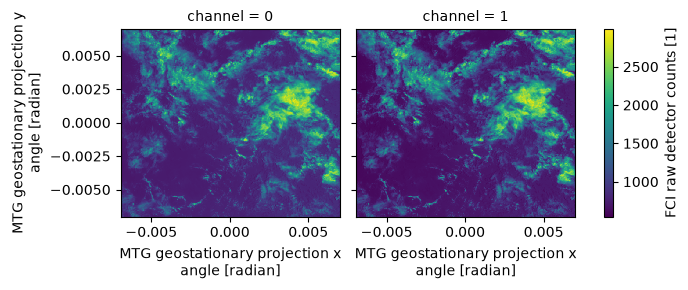

In [7]:
# XXX: all values appear to be 65535, which is the maximum value for a uint16.
# This seems to indicate that the data is not being read correctly. Perhaps the
# data is compressed in some way that xarray does not understand? Or perhaps
# the data is not actually stored in the zarr store at all, and instead is just
# a placeholder value?
da.plot(col="channel")
[da_.values for da_ in [da.min(), da.max(), da.mean()]]

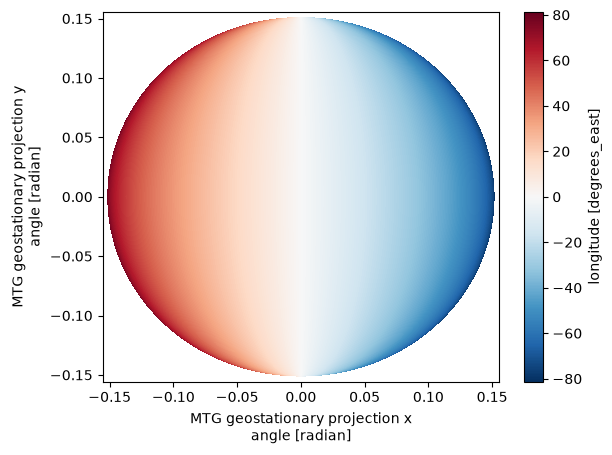

In [8]:
## full-disc view of the Earth visible from the satellite

# longitude and lattitude values are NaN outside of the "full disc" (i.e. where
# the Earth visible from the satellite). The NaN values are not plotted by
# default, so we can use this to visualize the Earth visible from the
# satellite.
da_lons = ds.longitude.load()
da_lons.plot()

In [9]:
# try loading all zarr groups as a datatree

store_url = "s3://fci-mtg.level1c.zarr/sample-data.zarr"

opts = {
    "anon": True,
    "client_kwargs": {"endpoint_url": "https://s3.r1.cloud.eumetsat.int"},
}

# loading works!
dt = xr.open_datatree(
    store_url,
    consolidated=False,
    storage_options=opts,
    create_default_indexes=False,
)
dt

/Users/B280936/git-repos/mlcast/mlcast-fci-mtg/.venv/lib/python3.12/site-packages/zarr/core/group.py:3289: ZarrUserWarning: Object at .firecube is not recognized as a component of a Zarr hierarchy.
  warnings.warn(


<xarray.DataTree>
Group: /
├── Group: /data_1km
│       Dimensions:        (channel: 8, time: 77406, y: 11136, x: 11136)
│       Coordinates:
│           time           (time) datetime64[s] 619kB ...
│           y              (y) float64 89kB ...
│           x              (x) float64 89kB ...
│           latitude       (y, x) float32 496MB ...
│           longitude      (y, x) float32 496MB ...
│       Dimensions without coordinates: channel
│       Data variables:
│           channel_name   (channel) |S16 128B ...
│           counts         (time, y, x, channel) uint16 154TB ...
│           offset         (time, channel) float64 5MB ...
│           pixel_time     (time, y, x, channel) datetime64[ns] 614TB ...
│           spatial_ref    int8 1B ...
│           pixel_quality  (time, y, x, channel) uint8 77TB ...
│           slope          (time, channel) float64 5MB ...
│       Attributes:
│           Conventions:  CF-1.8
│           title:        MTG FCI Level 1C effective radiances (1km)
│           institution:  EUMETSAT
│           source:       Meteosat Third Generation Flexible Combined Imager (FCI) Le...
│           history:      Ingested to Zarr by firecube-mtg-fci-l1c
└── Group: /data_2km
        Dimensions:        (channel: 8, time: 77406, y: 5568, x: 5568)
        Coordinates:
            time           (time) datetime64[s] 619kB ...
            y              (y) float64 45kB ...
            x              (x) float64 45kB ...
            latitude       (y, x) float32 124MB ...
            longitude      (y, x) float32 124MB ...
        Dimensions without coordinates: channel
        Data variables:
            spatial_ref    int8 1B ...
            channel_name   (channel) |S16 128B ...
            counts         (time, y, x, channel) uint16 38TB ...
            pixel_quality  (time, y, x, channel) uint8 19TB ...
            pixel_time     (time, y, x, channel) datetime64[ns] 154TB ...
            slope          (time, channel) float64 5MB ...
            offset         (time, channel) float64 5MB ...
        Attributes:
            Conventions:  CF-1.8
            title:        MTG FCI Level 1C effective radiances (2km)
            institution:  EUMETSAT
            source:       Meteosat Third Generation Flexible Combined Imager (FCI) Le...
            history:      Ingested to Zarr by firecube-mtg-fci-l1c

In [10]:
# XXX: xarray doesn't recognise the shared time coordinate across the datasets, so something needs to be changed here to allow for that
dt.coords

Coordinates:
    *empty*